In [1]:
#import libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import gdown
import json


from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1784941372.237145   32717 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784941372.237879   32717 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784941372.291621   32717 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784941373.315269   32717 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

CONFIG = json.loads(
    (ROOT / "config/project_config.json").read_text(encoding="utf-8")
)
keras.utils.set_random_seed(CONFIG["seed"])
tf.get_logger().setLevel("ERROR")

LABELS = CONFIG["bin_labels"]
CLASSES = np.arange(len(LABELS))
PRIMARY_HORIZON = int(CONFIG["primary_horizon"])
COMPARISON_HORIZON = int(CONFIG["comparison_horizon"])
VALIDATION_START_DATE = pd.Timestamp(CONFIG["validation_start_date"])
TEST_START_DATE = pd.Timestamp(CONFIG["test_start_date"])

two_data = pd.read_parquet(
    ROOT / f"data/sfo_delay_features_2h.parquet"
)
two_data = two_data.loc[two_data["target_delay_bin"].notna()]

In [3]:
print(f"2hr dataset shape: {two_data.shape}")

2hr dataset shape: (449387, 183)


In [4]:
train = two_data.loc[two_data["flight_date"] < VALIDATION_START_DATE].copy()
validation = two_data.loc[
    (two_data["flight_date"] >= VALIDATION_START_DATE)
    & (two_data["flight_date"] < TEST_START_DATE)
].copy()
test = two_data.loc[two_data["flight_date"] >= TEST_START_DATE].copy()

splits = {
    "Train": train,
    "Validation": validation,
    "Test": test,
}
split_summary = pd.DataFrame(
    {
        "split": list(splits.keys()),
        "rows": [len(frame) for frame in splits.values()],
        "start_date": [
            frame["flight_date"].min().date()
            for frame in splits.values()
        ],
        "end_date": [
            frame["flight_date"].max().date()
            for frame in splits.values()
        ],
    }
)
display(split_summary)

,split,rows,start_date,end_date
0,Train,293770,2022-01-01,2024-12-31
1,Validation,109971,2025-01-01,2025-12-31
2,Test,45646,2026-01-01,2026-05-31


In [5]:
NON_FEATURES = {
    "flight_id", "flight_date", "scheduled_dep_utc",
    "prediction_cutoff_utc", "prediction_horizon_hours",
    "dep_delay_minutes", "cancelled", "target_cancelled",
    "target_delay_ge_15", "target_delay_bin", "target_delay_bin_label",
    "eda_only_carrier_delay_minutes", "eda_only_weather_delay_minutes",
    "eda_only_nas_delay_minutes", "eda_only_security_delay_minutes",
    "eda_only_late_aircraft_delay_minutes",
}
FAA_FEATURES = {
    "aircraft_year_manufactured", "aircraft_type_code", "engine_type_code",
    "aircraft_manufacturer", "aircraft_model", "number_of_engines",
    "number_of_seats", "aircraft_weight_class", "aircraft_cruise_speed",
    "engine_thrust", "faa_record_type", "aircraft_age_years",
    "faa_match_flag",
}
LINEAGE_FEATURES = {
    "tail_sequence_today", "has_previous_tail_flight",
    "previous_flight_matches_origin", "previous_arrived_by_cutoff",
    "previous_departed_by_cutoff", "previous_arrival_delay_known",
    "previous_departure_delay_known", "scheduled_turnaround_minutes",
    "minutes_until_previous_scheduled_arrival",
    "minutes_since_previous_actual_arrival",
}

candidates = [column for column in train.columns if column not in NON_FEATURES]
training_missingness = 100 * train[candidates].isna().mean()
high_missing_features = training_missingness.loc[training_missingness >= 90].index.tolist()

FEATURES = [
    feature
    for feature in candidates
    if feature not in FAA_FEATURES
    and feature not in high_missing_features
]
CATEGORICAL_FEATURES = [
    feature
    for feature in FEATURES
    if pd.api.types.is_object_dtype(train[feature])
    or pd.api.types.is_string_dtype(train[feature])
]
NUMERIC_FEATURES = [feature for feature in FEATURES if feature not in CATEGORICAL_FEATURES]

feature_summary = pd.DataFrame(
    {
        "value": [
            len(candidates),
            len(high_missing_features),
            len(FAA_FEATURES.intersection(candidates)),
            len(FEATURES),
            len(LINEAGE_FEATURES.intersection(FEATURES)),
        ]
    },
    index=[
        "candidate features",
        "removed for missingness",
        "FAA features excluded",
        "final model features",
        "same-tail features retained",
    ],
)

display(feature_summary)
high_missing_table = training_missingness.reindex(high_missing_features)
high_missing_table = high_missing_table.sort_values(ascending=False).rename("missing_percent").round(2).to_frame()
display(high_missing_table)


,value
candidate features,167
removed for missingness,2
FAA features excluded,13
final model features,152
same-tail features retained,10


,missing_percent
origin_wind_gust_mps,90.33
origin_wind_gust_excess_mps,90.33


In [6]:
selected_missingness = (100 * train[FEATURES].isna().mean()).sort_values(ascending=False)
selected_missingness = selected_missingness.loc[selected_missingness.gt(0)]
display(selected_missingness.rename("missing_percent").round(2).to_frame())

,missing_percent
origin_wind_gust_max_prior_3h,78.81
previous_arrival_delay_known,62.21
minutes_since_previous_actual_arrival,62.21
carrier_destination_departures_delay_mean_6h,41.87
carrier_destination_departures_delay_ge_15_rate_6h,41.87
origin_precipitation_mm,26.37
origin_altimeter_hpa,21.45
carrier_sfo_arrivals_delay_mean_3h,18.23
carrier_sfo_arrivals_delay_ge_15_rate_3h,18.23
carrier_sfo_departures_delay_mean_3h,13.56


In [7]:
def prepare_model_data(frame):
    model_data = frame[FEATURES].copy()

    model_data[NUMERIC_FEATURES] = model_data[NUMERIC_FEATURES].apply(
        pd.to_numeric,
        errors="coerce",
    ).astype("float32")
    for column in CATEGORICAL_FEATURES:
        model_data[column] = model_data[column].astype(object).where(
            model_data[column].notna(),
            np.nan,
        )
    return model_data


def build_preprocessor():
    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler(with_mean=False)),
        ]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=25,
                    dtype=np.float32,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        sparse_threshold=1.0,
    )


development_preprocessor = build_preprocessor()
X_train = development_preprocessor.fit_transform(
    prepare_model_data(train)
).astype("float32")
X_validation = development_preprocessor.transform(
    prepare_model_data(validation)
).astype("float32")

y_train = train["target_delay_bin"].astype(int).to_numpy()
y_validation = validation["target_delay_bin"].astype(int).to_numpy()

transformed_summary = pd.DataFrame(
    {
        "rows": [X_train.shape[0], X_validation.shape[0]],
        "encoded_features": [X_train.shape[1], X_validation.shape[1]],
    },
    index=["Train", "Validation"],
)
display(transformed_summary)

,rows,encoded_features
Train,293770,219
Validation,109971,219


In [8]:
train

,flight_id,flight_date,scheduled_dep_utc,prediction_cutoff_utc,reporting_airline,dest,prediction_horizon_hours,dep_delay_minutes,cancelled,target_cancelled,...,aircraft_manufacturer,aircraft_model,number_of_engines,number_of_seats,aircraft_weight_class,aircraft_cruise_speed,engine_thrust,faa_record_type,aircraft_age_years,faa_match_flag
1,20220101_WN_2271.0_SFO_DEN_525,2022-01-01,2022-01-01 13:25:00+00:00,2022-01-01 11:25:00+00:00,WN,DEN,2,0.0,0,0,...,BOEING,737-76N,2,149,CLASS 3,0,0,MASTER,16,1
2,20220101_DL_1211.0_SFO_SLC_555,2022-01-01,2022-01-01 13:55:00+00:00,2022-01-01 11:55:00+00:00,DL,SLC,2,-3.0,0,0,...,AIRBUS CANADA LTD PTNRSP,BD-500-1A10,2,133,CLASS 3,0,19775,MASTER,3,1
3,20220101_AS_1124.0_SFO_SEA_600,2022-01-01,2022-01-01 14:00:00+00:00,2022-01-01 12:00:00+00:00,AS,SEA,2,2.0,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,0
4,20220101_DL_768.0_SFO_ATL_600,2022-01-01,2022-01-01 14:00:00+00:00,2022-01-01 12:00:00+00:00,DL,ATL,2,14.0,0,0,...,BOEING,757-351,2,275,CLASS 3,0,40900,MASTER,20,1
5,20220101_UA_2604.0_SFO_LAX_602,2022-01-01,2022-01-01 14:02:00+00:00,2022-01-01 12:02:00+00:00,UA,LAX,2,-6.0,0,0,...,BOEING,737-824,2,149,CLASS 3,0,27300,MASTER,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297855,20241231_UA_2097.0_SFO_ORD_2335,2024-12-31,2025-01-01 07:35:00+00:00,2025-01-01 05:35:00+00:00,UA,ORD,2,41.0,0,0,...,BOEING,777-222,2,400,CLASS 3,0,60000,MASTER,28,1
297856,20241231_UA_2423.0_SFO_BWI_2352,2024-12-31,2025-01-01 07:52:00+00:00,2025-01-01 05:52:00+00:00,UA,BWI,2,-10.0,0,0,...,BOEING,737-9,2,48,CLASS 3,0,29317,MASTER,6,1
297857,20241231_UA_1385.0_SFO_EWR_2355,2024-12-31,2025-01-01 07:55:00+00:00,2025-01-01 05:55:00+00:00,UA,EWR,2,4.0,0,0,...,BOEING,757-224,2,178,CLASS 3,0,22000,MASTER,30,1
297858,20241231_AA_2799.0_SFO_MIA_2358,2024-12-31,2025-01-01 07:58:00+00:00,2025-01-01 05:58:00+00:00,AA,MIA,2,-2.0,0,0,...,AIRBUS,A321-253N,2,222,CLASS 3,0,32160,MASTER,5,1


In [9]:
def build_delay_model(n_features, n_classes):
    inputs = keras.Input(
        shape=(n_features,),
        name="encoded_flight_features"
    )

    x = keras.layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.30)(x)

    x = keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.25)(x)

    x = keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = keras.layers.Dropout(0.20)(x)

    outputs = keras.layers.Dense(
        n_classes,
        activation="softmax",
        name="delay_bin_probabilities"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="flight_delay_classifier"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model


In [10]:
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))

delay_model = build_delay_model(
    n_features=n_features,
    n_classes=n_classes
)

delay_model.summary()

E0000 00:00:1784941389.302558   32717 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1784941389.302923   32807 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1784941380.700154   32717 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "flight_delay_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoded_flight_features         │ (None, 219)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        56,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ delay_bin_probabilities (Dense) │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,333 (388.02 KB)

 Trainable params: 98,565 (385.02 KB)

 Non-trainable params: 768 (3.00 KB)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

def make_sample_weights(y):
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(n_classes),
        y=y
    )

    softened_weights = np.sqrt(class_weights)

    return softened_weights[y]

training_weights = make_sample_weights(y_train)

history = delay_model.fit(
    X_train,
    y_train,
    sample_weight=training_weights,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=40,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
574/574 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7274 - loss: 0.9454 - val_accuracy: 0.0853 - val_loss: 2.2549 - learning_rate: 0.0010
Epoch 2/40
574/574 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7842 - loss: 0.8489 - val_accuracy: 0.7647 - val_loss: 0.9142 - learning_rate: 0.0010
Epoch 3/40
574/574 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7906 - loss: 0.8280 - val_accuracy: 0.0221 - val_loss: 3.4004 - learning_rate: 0.0010
Epoch 4/40
574/574 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7928 - loss: 0.8173
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
574/574 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7941 - loss: 0.8189 - val_accuracy: 0.6953 - val_loss: 0.9577 - learning_rate: 0.0010
Epoch 5/40
574/574 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7956 - loss: 0.8086 - val_accuracy: 0.3426 - val_loss: 1.4666 - learning_rate: 5.0000e-04
Epoch 6/40
  8/574 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8069 - loss: 0.7

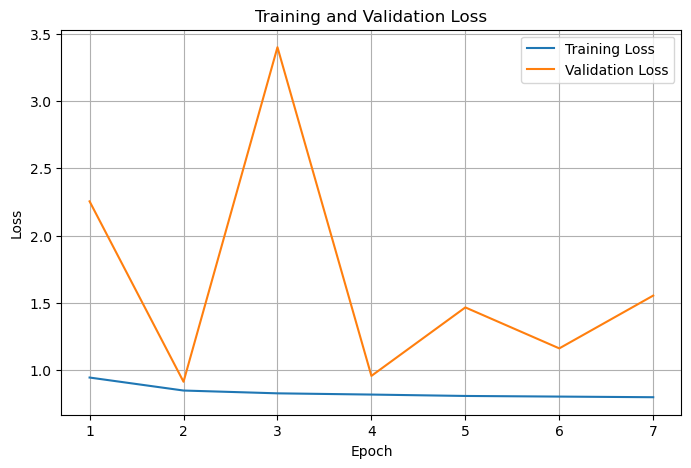

In [12]:

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    epochs,
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

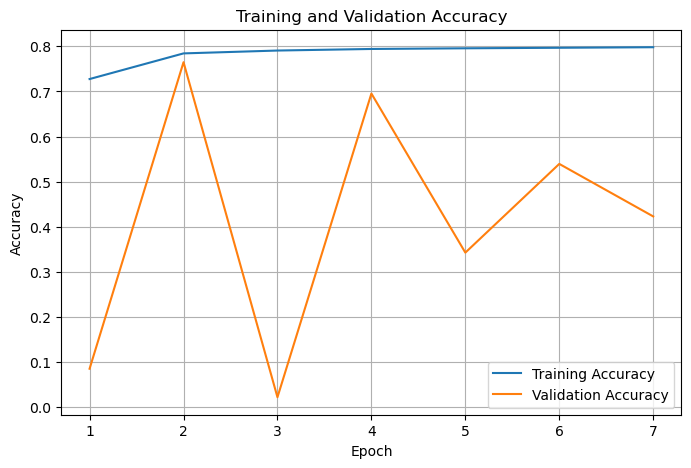

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    epochs,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [14]:
validation_probabilities = delay_model.predict(
    X_validation,
    batch_size=1024,
    verbose=0
)

validation_predictions = validation_probabilities.argmax(axis=1)

print("Probability shape:", validation_probabilities.shape)
print("Prediction shape:", validation_predictions.shape)

Probability shape: (109971, 5)
Prediction shape: (109971,)


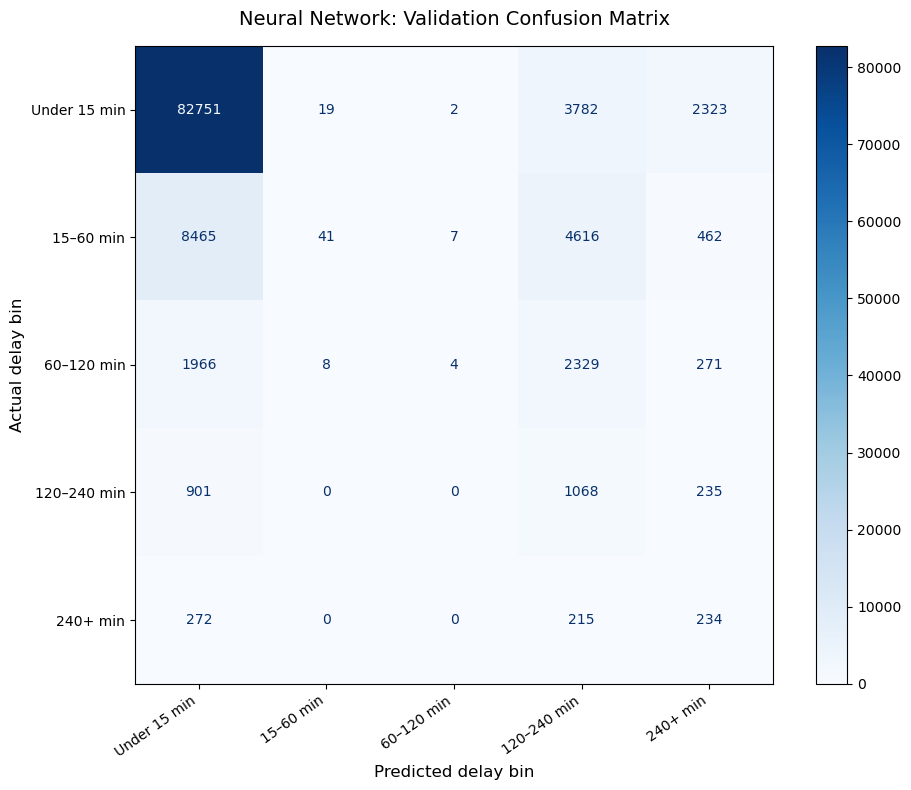

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_true=y_validation,
    y_pred=validation_predictions,
    labels=CLASSES,
    display_labels=chart_labels,
    normalize=None,
    cmap="Blues",
    values_format="d",
    colorbar=True,
    ax=ax
)

ax.set_title(
    "Neural Network: Validation Confusion Matrix",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Predicted delay bin", fontsize=12)
ax.set_ylabel("Actual delay bin", fontsize=12)

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()